In [71]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


project_directory = Path(
    r"C:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents"
    r"\IMDB_WEEK1_SIX\movie-embeddings-project"
)

movies_df = pd.read_csv(
    project_directory
    / "data"
    / "processed"
    / "movies_cleaned.csv"
).reset_index(drop=True)

genres_df = pd.read_csv(
    project_directory
    / "artifacts"
    / "metadata"
    / "movie_genres.csv"
)

genres_df["genres_set"] = genres_df["genres"].apply(lambda x: set(ast.literal_eval(x)))

gte_embeddings = np.load(
    project_directory
    / "artifacts"
    / "embeddings"
    / "gte_modernbert_embeddings.npy"
).astype(np.float32)

gte_embeddings = normalize(
    gte_embeddings,
    norm="l2",
    axis=1,
)

print(gte_embeddings.shape)

from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances,
    manhattan_distances,
)

(9967, 768)


In [76]:
genres_df.columns

Index(['movie_id', 'tmdb_title', 'genre_ids', 'genres', 'genre_count',
       'status', 'dataset_title', 'genres_set'],
      dtype='str')

In [62]:
query_titles = [
    "The Dark Knight",
    "Inception",
    "Toy Story",
    "The Godfather",
    "The Matrix",
    "Titanic",
    "Alien",
    "The Exorcist",
    "Saving Private Ryan",
    "Finding Nemo",
]

In [63]:
comparison_rows = []

for title in query_titles:
    query_index = movies_df[
        movies_df["title"].str.casefold() == title.casefold()
    ].index[0]

    query_embedding = gte_embeddings[
        query_index
    ].reshape(1, -1)

    cosine_scores = cosine_similarity(
        query_embedding,
        gte_embeddings,
    )[0]

    euclidean_scores = euclidean_distances(
        query_embedding,
        gte_embeddings,
    )[0]

    manhattan_scores = manhattan_distances(
        query_embedding,
        gte_embeddings,
    )[0]

    cosine_scores[query_index] = -1
    euclidean_scores[query_index] = np.inf
    manhattan_scores[query_index] = np.inf

    cosine_indices = cosine_scores.argsort()[::-1][:10]
    euclidean_indices = euclidean_scores.argsort()[:10]
    manhattan_indices = manhattan_scores.argsort()[:10]

    cosine_set = set(
        movies_df.iloc[cosine_indices]["movie_id"]
    )

    euclidean_set = set(
        movies_df.iloc[euclidean_indices]["movie_id"]
    )

    manhattan_set = set(
        movies_df.iloc[manhattan_indices]["movie_id"]
    )

    comparison_rows.append(
        {
            "title": title,
            "cosine_euclidean_overlap": len(
                cosine_set & euclidean_set
            ),
            "cosine_manhattan_overlap": len(
                cosine_set & manhattan_set
            ),
            "euclidean_manhattan_overlap": len(
                euclidean_set & manhattan_set
            ),
        }
    )

metric_overlap_df = pd.DataFrame(comparison_rows)

display(metric_overlap_df)

,title,cosine_euclidean_overlap,cosine_manhattan_overlap,euclidean_manhattan_overlap
0,The Dark Knight,10,10,10
1,Inception,10,8,8
2,Toy Story,10,9,9
3,The Godfather,10,7,7
4,The Matrix,10,9,9
5,Titanic,10,6,6
6,Alien,10,9,9
7,The Exorcist,10,10,10
8,Saving Private Ryan,10,9,9
9,Finding Nemo,10,9,9


In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


RANDOM_STATE = 42
k_values = range(2, 13)
silhouette_scores = []

kmeans_evaluation_rows = []



for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
        )

    labels = kmeans.fit_predict(gte_embeddings)

    score = silhouette_score(
        gte_embeddings,
        labels,
        metric="euclidean",
        random_state=RANDOM_STATE,
        )

    silhouette_scores.append(score)

    print(
        f"k={k:} | "
        f"inertia={kmeans.inertia_:,.2f} | "
        f"silhouette={score:.4f}"
        )




k=2 | inertia=4,302.72 | silhouette=0.0277
k=3 | inertia=4,230.05 | silhouette=0.0232
k=4 | inertia=4,183.86 | silhouette=0.0194
k=5 | inertia=4,144.76 | silhouette=0.0194
k=6 | inertia=4,113.37 | silhouette=0.0194
k=7 | inertia=4,087.06 | silhouette=0.0200
k=8 | inertia=4,062.13 | silhouette=0.0186
k=9 | inertia=4,037.82 | silhouette=0.0195
k=10 | inertia=4,017.12 | silhouette=0.0170
k=11 | inertia=3,999.50 | silhouette=0.0171
k=12 | inertia=3,982.70 | silhouette=0.0169


In [74]:
final_k = 7

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20,
)

movies_df["cluster"] = kmeans.fit_predict(gte_embeddings)

movies_df["cluster"].value_counts().sort_index()

cluster
0    1727
1    1391
2    1000
3    1161
4    1733
5    1733
6    1222
Name: count, dtype: int64

In [78]:
cluster_genres_df = movies_df[
    ["movie_id", "title", "cluster"]
].merge(
    genres_df[["movie_id", "genres_set"]],
    on="movie_id",
    how="left",
)

In [80]:
cluster_genres_exploded = cluster_genres_df.explode("genres_set")

In [81]:
top_genres_by_cluster = (
    cluster_genres_exploded
    .groupby(["cluster", "genres_set"])
    .size()
    .reset_index(name="count")
    .sort_values(
        ["cluster", "count"],
        ascending=[True, False],
    )
    .groupby("cluster")
    .head(5)
)

display(top_genres_by_cluster)

,cluster,genres_set,count
5,0,Drama,1230
3,0,Comedy,736
12,0,Romance,273
15,0,Thriller,206
4,0,Crime,163
21,1,Comedy,853
24,1,Family,639
20,1,Animation,439
19,1,Adventure,437
23,1,Drama,418


In [83]:
import numpy as np


representative_rows = []

for cluster_id in range(7):
    cluster_indices = np.flatnonzero(movies_df["cluster"] == cluster_id)
    cluster_embeddings = gte_embeddings[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)

    similarities = cluster_embeddings @ centroid

    top_positions = np.argsort(similarities)[::-1][:5]
    top_indices = cluster_indices[top_positions]

    for rank, movie_index in enumerate(top_indices, start=1):
        representative_rows.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "title": movies_df.iloc[movie_index]["title"],
                "overview": movies_df.iloc[movie_index]["overview"],
                "centroid_similarity": similarities[top_positions[rank - 1]],
            }
        )

representative_movies = pd.DataFrame(representative_rows)

display(representative_movies)

,cluster,rank,title,overview,centroid_similarity
0,0,1,Black Box,After losing his wife and his memory in a car ...,0.835614
1,0,2,The Eighth Day,"Georges has Down syndrome, living at a mental-...",0.832172
2,0,3,Kabhi Khushi Kabhie Gham,Years after his father disowns his adopted bro...,0.831391
3,0,4,The Do-Over,The life of a bank manager is turned upside do...,0.831089
4,0,5,About Schmidt,A recently retired man embarks on a journey to...,0.828280
5,1,1,"The Boy, the Mole, the Fox and the Horse","The unlikely friendship of a boy, a mole, a fo...",0.835834
6,1,2,The Package,When a group of teenagers goes on a spring bre...,0.827999
7,1,3,House of Wax,A group of unwitting teens are stranded near a...,0.824970
8,1,4,Free Willy,When maladjusted orphan Jesse vandalizes a the...,0.824795
9,1,5,Mandibles,When two simple-minded best friends find a gia...,0.823634


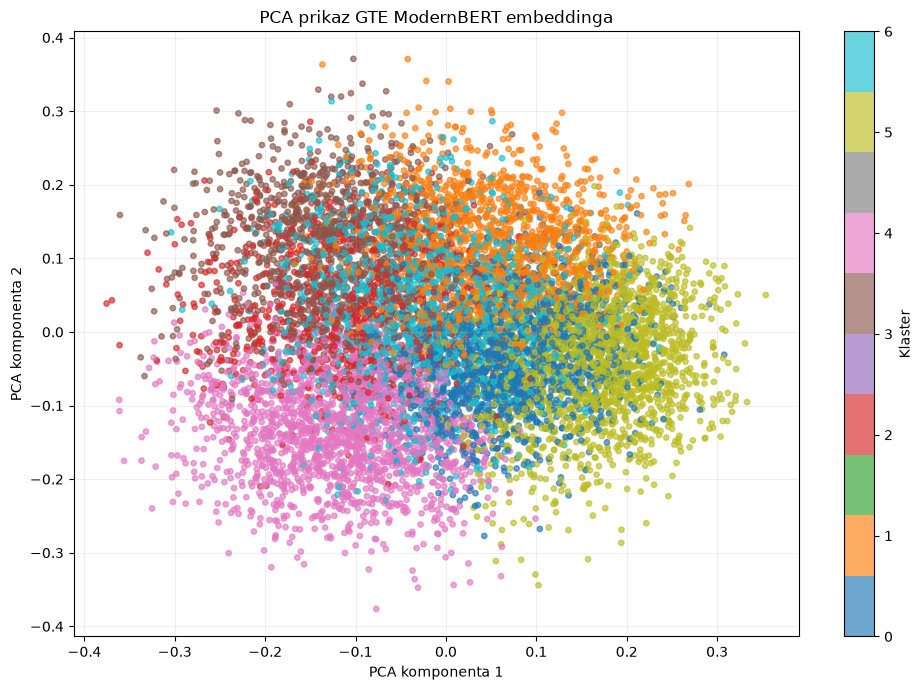

Objašnjena varijansa prve dve komponente: 0.0696154


In [85]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(gte_embeddings)

movies_df["pca_1"] = embeddings_2d[:, 0]
movies_df["pca_2"] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    movies_df["pca_1"],
    movies_df["pca_2"],
    c=movies_df["cluster"],
    cmap="tab10",
    s=15,
    alpha=0.65
)

plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.title("PCA prikaz GTE ModernBERT embeddinga")
plt.colorbar(scatter, label="Klaster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Objašnjena varijansa prve dve komponente:",
    pca.explained_variance_ratio_.sum()
)

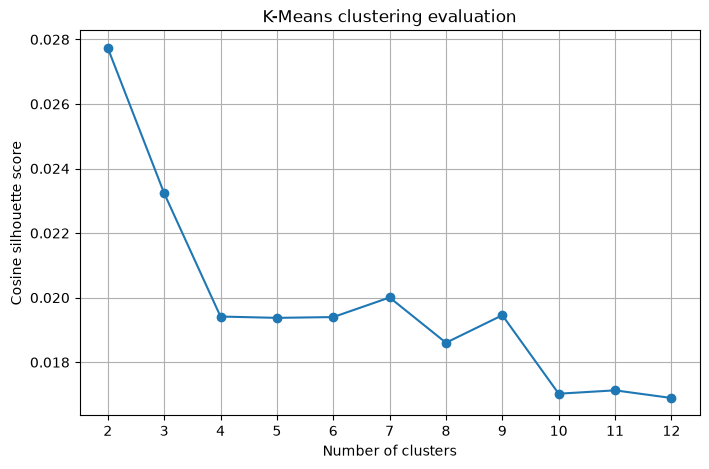

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Cosine silhouette score")
plt.title("K-Means clustering evaluation")
plt.xticks(list(k_values))
plt.grid()
plt.show()

In [42]:
import numpy as np


representative_rows = []

for cluster_id in range(7):
    cluster_indices = np.flatnonzero(gte_labels_7 == cluster_id)
    cluster_embeddings = x_gte[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)

    similarities = cluster_embeddings @ centroid

    top_positions = np.argsort(similarities)[::-1][:5]
    top_indices = cluster_indices[top_positions]

    for rank, movie_index in enumerate(top_indices, start=1):
        representative_rows.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "title": movies_df.iloc[movie_index]["title"],
                "overview": movies_df.iloc[movie_index]["overview"],
                "centroid_similarity": similarities[top_positions[rank - 1]],
            }
        )

representative_movies = pd.DataFrame(representative_rows)

display(representative_movies)

c:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents\IMDB_WEEK1_SIX\.venv\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,cluster,rank,title,overview,centroid_similarity
0,0,1,Black Box,After losing his wife and his memory in a car ...,0.835449
1,0,2,The Eighth Day,"Georges has Down syndrome, living at a mental-...",0.832031
2,0,3,The Do-Over,The life of a bank manager is turned upside do...,0.831543
3,0,4,Kabhi Khushi Kabhie Gham,Years after his father disowns his adopted bro...,0.831543
4,0,5,About Schmidt,A recently retired man embarks on a journey to...,0.828613
5,1,1,"The Boy, the Mole, the Fox and the Horse","The unlikely friendship of a boy, a mole, a fo...",0.835938
6,1,2,The Package,When a group of teenagers goes on a spring bre...,0.827637
7,1,3,Free Willy,When maladjusted orphan Jesse vandalizes a the...,0.824707
8,1,4,House of Wax,A group of unwitting teens are stranded near a...,0.824707
9,1,5,Mandibles,When two simple-minded best friends find a gia...,0.823242


Explained variance: [0.03971357 0.02990147] Total explained variance: 0.06961504103170679


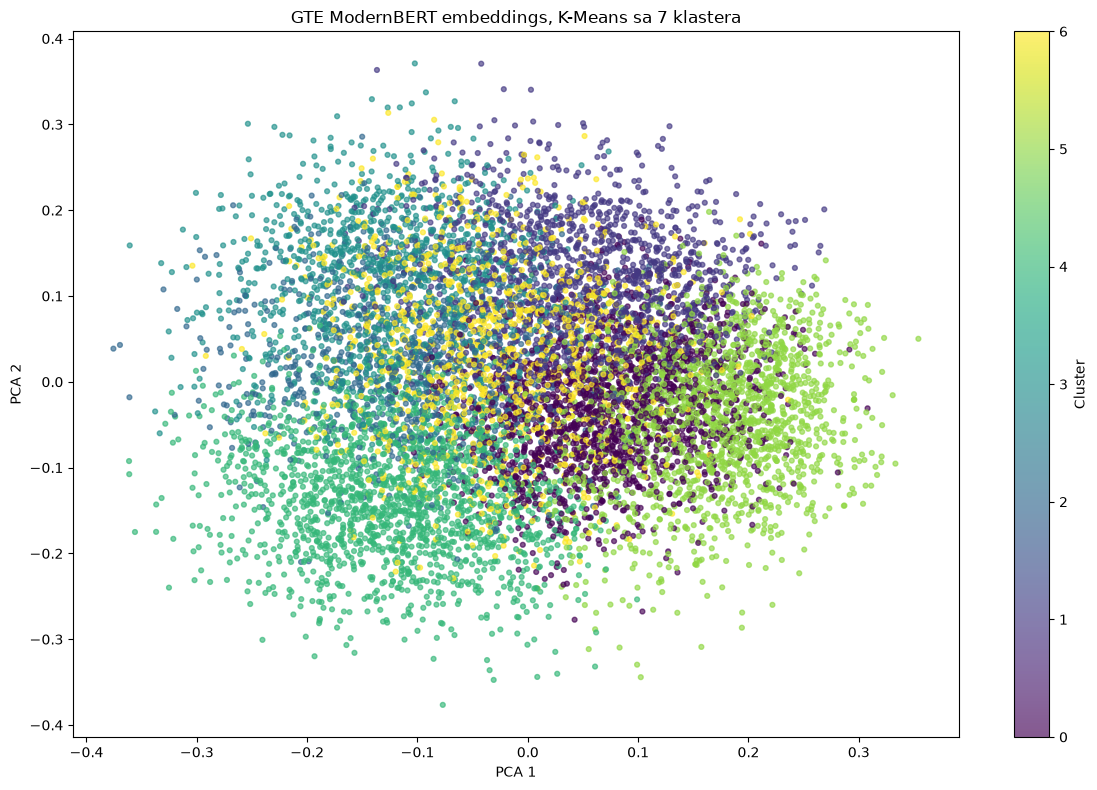

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize


# GTE embeddingi
x_gte = normalize(
    embeddings["gte_modernbert"],
    norm="l2",
    axis=1,
)

# PCA redukcija na 2 dimenzije samo za vizualizaciju
pca_2d = PCA(
    n_components=2,
    random_state=42,
)

gte_pca_2d = pca_2d.fit_transform(x_gte)

plot_df = pd.DataFrame(
    {
        "pca_1": gte_pca_2d[:, 0],
        "pca_2": gte_pca_2d[:, 1],
        "cluster": gte_labels_7,
        "title": movies_df["title"].to_numpy(),
        "overview": movies_df["overview"].to_numpy(),
    }
)

print(
    "Explained variance:",
    pca_2d.explained_variance_ratio_,
    "Total explained variance:",
    pca_2d.explained_variance_ratio_.sum(),
)


plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df["pca_1"],
    plot_df["pca_2"],
    c=plot_df["cluster"],
    s=12,
    alpha=0.65,
)

plt.colorbar(scatter, label="Cluster")
plt.title("GTE ModernBERT embeddings, K-Means sa 7 klastera")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

Varijansa sačuvana u 50 PCA komponenti: 0.51509553
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 9967 samples in 0.002s...
[t-SNE] Computed neighbors for 9967 samples in 1.883s...
[t-SNE] Computed conditional probabilities for sample 1000 / 9967
[t-SNE] Computed conditional probabilities for sample 2000 / 9967
[t-SNE] Computed conditional probabilities for sample 3000 / 9967
[t-SNE] Computed conditional probabilities for sample 4000 / 9967
[t-SNE] Computed conditional probabilities for sample 5000 / 9967
[t-SNE] Computed conditional probabilities for sample 6000 / 9967
[t-SNE] Computed conditional probabilities for sample 7000 / 9967
[t-SNE] Computed conditional probabilities for sample 8000 / 9967
[t-SNE] Computed conditional probabilities for sample 9000 / 9967
[t-SNE] Computed conditional probabilities for sample 9967 / 9967
[t-SNE] Mean sigma: 0.211644
[t-SNE] KL divergence after 50 iterations with early exaggeration: 87.927406
[t-SNE] KL divergence after 1000 iteratio

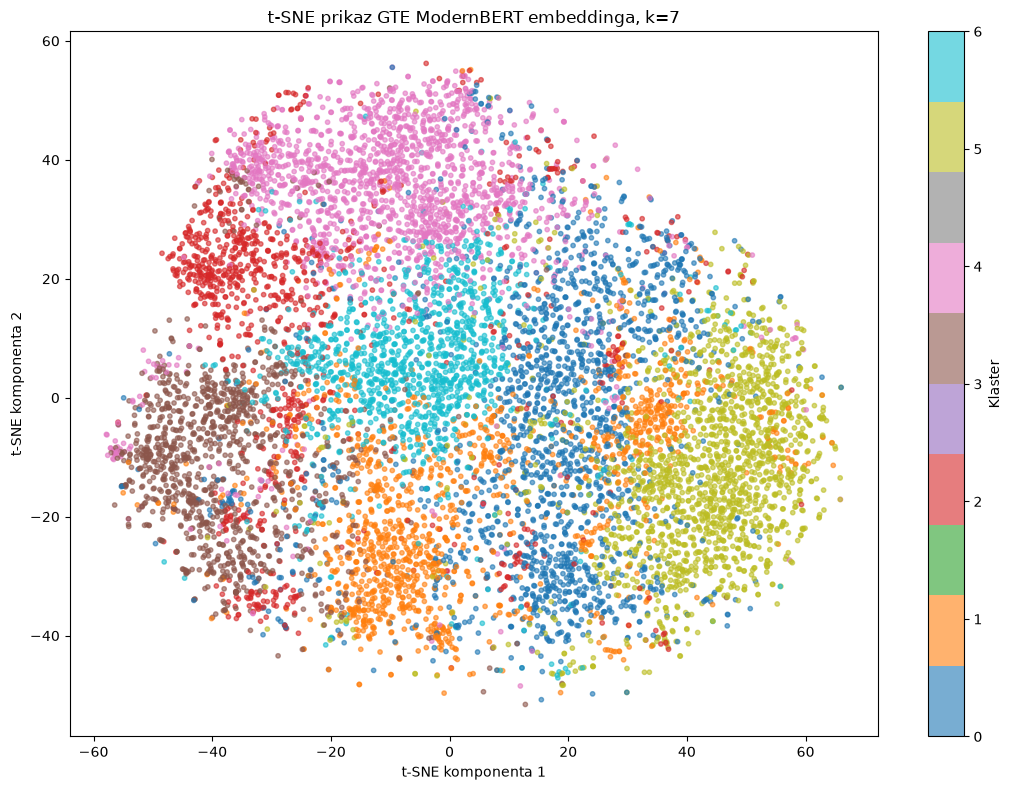

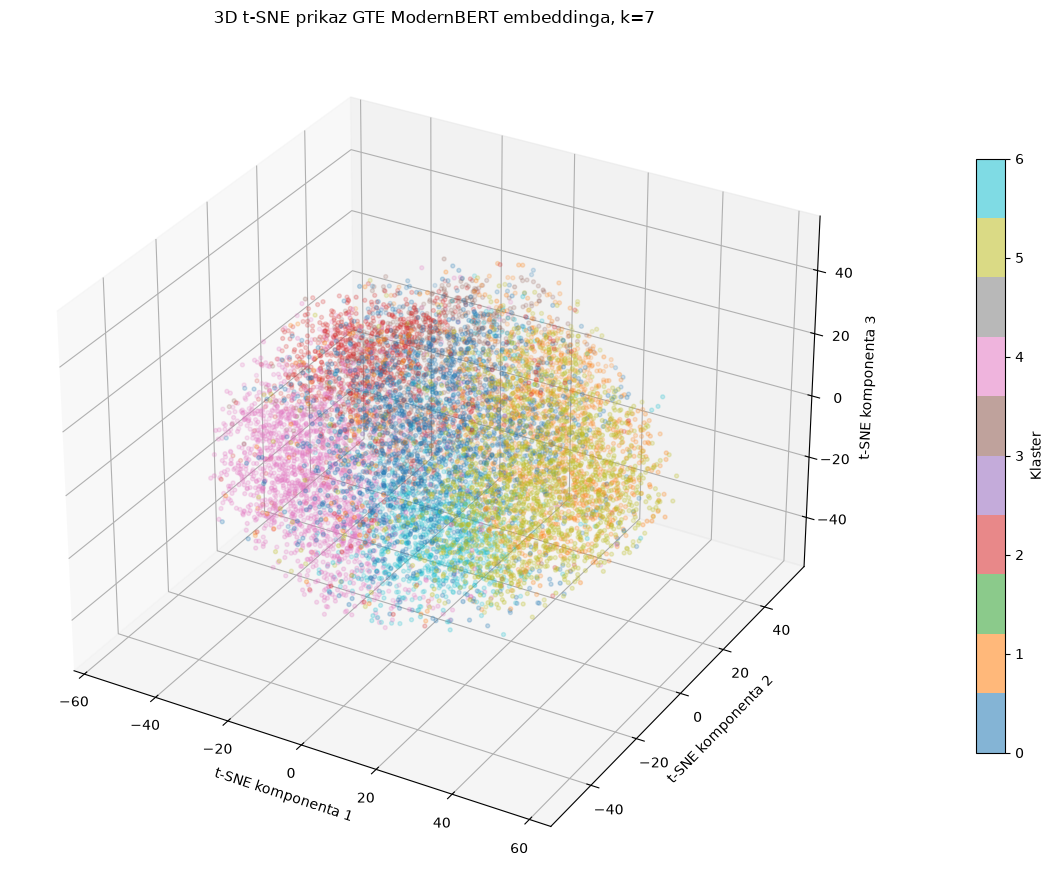

In [94]:
#ideja prvo na 50 dimenzija pa t-SNE u 2

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Pre-redukcija sa 768 na 50 dimenzija
pca_50 = PCA(
    n_components=50,
    random_state=42
)

embeddings_pca_50 = pca_50.fit_transform(gte_embeddings)

print(
    "Varijansa sačuvana u 50 PCA komponenti:",
    pca_50.explained_variance_ratio_.sum()
)

# 2. Nelinearna projekcija sa 50 na 2 dimenzije
tsne = TSNE(
    n_components=2,
    perplexity=50,
    metric="cosine",
    init="pca",
    learning_rate="auto",
    method="barnes_hut",
    angle=0.5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# t-SNE projekcija u 3D
tsne_3d = TSNE(
    n_components=3,
    perplexity=50,
    metric="cosine",
    init="pca",
    learning_rate="auto",
    method="barnes_hut",
    angle=0.5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

embeddings_tsne = tsne.fit_transform(embeddings_pca_50)
embeddings_tsne_3d = tsne_3d.fit_transform(embeddings_pca_50)

movies_df["tsne_2d_1"] = embeddings_tsne[:, 0]
movies_df["tsne_2d_2"] = embeddings_tsne[:, 1]

movies_df["tsne_3d_1"] = embeddings_tsne_3d[:, 0]
movies_df["tsne_3d_2"] = embeddings_tsne_3d[:, 1]
movies_df["tsne_3d_3"] = embeddings_tsne_3d[:, 2]

# 3. Prikaz postojećih K-Means klastera
plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    movies_df["tsne_2d_1"],
    movies_df["tsne_2d_2"],
    c=movies_df["cluster"],
    cmap="tab10",
    s=10,
    alpha=0.6,
    rasterized=True
)

plt.xlabel("t-SNE komponenta 1")
plt.ylabel("t-SNE komponenta 2")
plt.title("t-SNE prikaz GTE ModernBERT embeddinga, k=7")
plt.colorbar(scatter, label="Klaster")
plt.tight_layout()
plt.show()



# 3D prikaz
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    movies_df["tsne_3d_1"],
    movies_df["tsne_3d_2"],
    movies_df["tsne_3d_3"],
    c=movies_df["cluster"],
    cmap="tab10",
    s=8,
    alpha=0.55,
    rasterized=True
)

ax.set_xlabel("t-SNE komponenta 1")
ax.set_ylabel("t-SNE komponenta 2")
ax.set_zlabel("t-SNE komponenta 3")
ax.set_title("3D t-SNE prikaz GTE ModernBERT embeddinga, k=7")

fig.colorbar(scatter, ax=ax, label="Klaster", shrink=0.7, pad=0.1)

plt.tight_layout()
plt.show()

In [ ]:
movies_df = movies_df.drop(columns="genres", errors="ignore")

genre_map = (
    genres_df
    .drop_duplicates("movie_id")
    .set_index("movie_id")["genres"]
)

movies_df["genres"] = movies_df["movie_id"].map(genre_map)


Nedostajući žanrovi: 0


In [97]:
import numpy as np
import pandas as pd

representative_movies = []

for cluster_id in sorted(movies_df["cluster"].unique()):
    cluster_indices = np.where(movies_df["cluster"].to_numpy() == cluster_id)[0]
    cluster_embeddings = gte_embeddings[cluster_indices]

    # Centroid klastera
    centroid = cluster_embeddings.mean(axis=0)

    # Udaljenost svakog filma od centroida
    distances = np.linalg.norm(
        cluster_embeddings - centroid,
        axis=1
    )

    # Pet filmova najbližih centroidu
    closest_local_indices = np.argsort(distances)[:5]
    closest_df_indices = cluster_indices[closest_local_indices]

    cluster_movies = movies_df.iloc[closest_df_indices][
        ["title", "genres", "overview"]
    ].copy()

    cluster_movies.insert(0, "cluster", cluster_id)
    cluster_movies.insert(1, "rank", range(1, len(cluster_movies) + 1))
    cluster_movies["centroid_distance"] = distances[closest_local_indices]

    representative_movies.append(cluster_movies)

representative_movies_df = pd.concat(
    representative_movies,
    ignore_index=True
)

representative_movies_df

,cluster,rank,title,genres,overview,centroid_distance
0,0,1,Black Box,"[""Horror"", ""Science Fiction""]",After losing his wife and his memory in a car ...,0.555048
1,0,2,The Eighth Day,"[""Drama""]","Georges has Down syndrome, living at a mental-...",0.559718
2,0,3,Kabhi Khushi Kabhie Gham,"[""Comedy"", ""Drama""]",Years after his father disowns his adopted bro...,0.560771
3,0,4,The Do-Over,"[""Action"", ""Adventure"", ""Comedy""]",The life of a bank manager is turned upside do...,0.561178
4,0,5,About Schmidt,"[""Drama"", ""Comedy""]",A recently retired man embarks on a journey to...,0.564951
5,1,1,"The Boy, the Mole, the Fox and the Horse","[""Animation"", ""Family"", ""Drama"", ""Adventure""]","The unlikely friendship of a boy, a mole, a fo...",0.554779
6,1,2,The Package,"[""Comedy""]",When a group of teenagers goes on a spring bre...,0.565353
7,1,3,House of Wax,"[""Horror"", ""Thriller"", ""Mystery""]",A group of unwitting teens are stranded near a...,0.569387
8,1,4,Free Willy,"[""Family"", ""Adventure"", ""Drama""]",When maladjusted orphan Jesse vandalizes a the...,0.569620
9,1,5,Mandibles,"[""Comedy"", ""Fantasy""]",When two simple-minded best friends find a gia...,0.571159
